# Evaluación individual por algoritmo — SATRA EM 2022
**Proyecto P20261012 · UPC · Taller de Proyectos I**

Cada sección evalúa un algoritmo de forma independiente con métricas de CV (AUC, F1, Precision, Recall, Accuracy), curva ROC y matriz de confusión.

**Cómo usarlo:** ejecuta las celdas de Setup una sola vez al inicio, luego corre cada sección por separado y toma captura.

## Setup — ejecutar una sola vez al inicio

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

ROOT = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT / 'modelo'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score, accuracy_score,
    confusion_matrix, roc_curve,
)
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from em2022.pipeline.config import (
    SEED, DATASET, TARGET, GROUP_COL, ALL_FEATURES, MONOTONIC_CONSTRAINTS
)
from em2022.pipeline.preprocessing import add_ie_features, make_pipeline

COLOR_ALTO   = '#dc2626'
COLOR_MEDIO  = '#d97706'
COLOR_BAJO   = '#16a34a'
COLOR_NAVY   = '#0f1f3d'
COLOR_ACCENT = '#2563eb'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8fafc',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

In [11]:
EXCEL_PATH = ROOT / 'modelo' / 'data' / 'EM_2S_2022_alumnos_innominado.xlsx'
df_raw = pd.read_excel(EXCEL_PATH, sheet_name='BD')

df = df_raw[df_raw['Departamento'].str.upper() == 'LIMA'].copy()

for col in ['M500_L', 'M500_CN', 'M500_M', 'ise']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Grupos 'En inicio' y 'Previo al Inicio' se consideran en riesgo
df['riesgo_matematica'] = df['grupo_M'].isin(['En inicio', 'Previo al Inicio']).astype(int)
df = df.dropna(subset=['M500_L', 'M500_CN', 'ise', 'grupo_M'])

n_total = len(df)
n_ies   = df[GROUP_COL].nunique()

print(f'Lima: {n_total:,} estudiantes | {n_ies} IEs | {df["Distrito"].nunique()} distritos')
print(f'En riesgo: {df[TARGET].mean()*100:.1f}%')

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(gss.split(df, df[TARGET], groups=df[GROUP_COL]))
train_df = add_ie_features(df.iloc[train_idx], df.iloc[train_idx])
test_df  = add_ie_features(df.iloc[train_idx], df.iloc[test_idx])

X_train = train_df[ALL_FEATURES];  y_train = train_df[TARGET].values
X_test  = test_df[ALL_FEATURES];   y_test  = test_df[TARGET].values
g_train = train_df[GROUP_COL].values

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
cv = GroupKFold(n_splits=5)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,} | Positivos train: {y_train.mean()*100:.1f}%')

Lima: 11,955 estudiantes | 223 IEs | 67 distritos
En riesgo: 53.8%
Train: 9,741 | Test: 2,214 | Positivos train: 52.5%


In [12]:
def evaluar_y_graficar(nombre, pipe, color=COLOR_ACCENT):
    print(f'\nEvaluando {nombre} con GroupKFold(5)...')

    scores = cross_validate(
        pipe, X_train, y_train, cv=cv, groups=g_train,
        scoring={'auc':'roc_auc','f1':'f1','precision':'precision','recall':'recall','accuracy':'accuracy'},
        n_jobs=-1
    )

    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.50).astype(int)

    auc_test  = roc_auc_score(y_test, y_prob)
    f1_test   = f1_score(y_test, y_pred)
    prec_test = precision_score(y_test, y_pred)
    rec_test  = recall_score(y_test, y_pred)
    acc_test  = accuracy_score(y_test, y_pred)
    cm        = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    fig = plt.figure(figsize=(15, 9))
    fig.patch.set_facecolor('white')
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
    fig.suptitle(f'Evaluación — {nombre}', fontsize=16, fontweight='bold', color=COLOR_NAVY, y=0.98)

    # Panel métricas
    ax_met = fig.add_subplot(gs[0, 0])
    ax_met.axis('off')
    metricas = [
        ('AUC-ROC (test)',  f'{auc_test:.4f}',  COLOR_ACCENT),
        ('AUC-ROC (CV)',    f'{scores["test_auc"].mean():.4f} ± {scores["test_auc"].std():.4f}', COLOR_NAVY),
        ('F1-Score (test)', f'{f1_test:.4f}',   COLOR_ACCENT),
        ('Precision',       f'{prec_test:.4f}', COLOR_MEDIO),
        ('Recall',          f'{rec_test:.4f}',  COLOR_BAJO),
        ('Accuracy',        f'{acc_test:.4f}',  '#64748b'),
    ]
    for i, (label, val, col) in enumerate(metricas):
        y_pos = 0.92 - i * 0.16
        ax_met.text(0.02, y_pos, label, transform=ax_met.transAxes, fontsize=10, color='#64748b')
        ax_met.text(0.98, y_pos, val, transform=ax_met.transAxes, fontsize=11, fontweight='bold', color=col, ha='right')
        if i < len(metricas) - 1:
            ax_met.axhline(y=y_pos - 0.04, xmin=0, xmax=1, color='#e2e8f0', linewidth=0.8)
    ax_met.set_title('Métricas clave', pad=10)
    ax_met.set_xlim(0, 1); ax_met.set_ylim(0, 1)
    for spine in ax_met.spines.values(): spine.set_visible(False)

    # Curva ROC
    ax_roc = fig.add_subplot(gs[0, 1])
    ax_roc.plot(fpr, tpr, color=color, lw=2.5, label=f'ROC (AUC = {auc_test:.3f})')
    ax_roc.plot([0,1],[0,1],'--', color='#94a3b8', lw=1.5, label='Azar')
    ax_roc.fill_between(fpr, tpr, alpha=0.08, color=color)
    ax_roc.set_xlabel('Tasa de Falsos Positivos'); ax_roc.set_ylabel('Tasa de Verdaderos Positivos')
    ax_roc.set_title('Curva ROC')
    ax_roc.legend(fontsize=9); ax_roc.set_xlim(0,1); ax_roc.set_ylim(0,1)
    ax_roc.grid(True, alpha=0.3)

    # Matriz de confusión
    ax_cm = fig.add_subplot(gs[0, 2])
    ax_cm.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax_cm.set_title('Matriz de confusión')
    ax_cm.set_xticks([0,1]); ax_cm.set_yticks([0,1])
    ax_cm.set_xticklabels(['Sin riesgo', 'En riesgo'], fontsize=9)
    ax_cm.set_yticklabels(['Sin riesgo', 'En riesgo'], fontsize=9)
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax_cm.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=16, fontweight='bold',
                       color='white' if cm[i,j] > thresh else COLOR_NAVY)
    ax_cm.set_ylabel('Real'); ax_cm.set_xlabel('Predicho')

    # Métricas por fold
    ax_folds = fig.add_subplot(gs[1, 0])
    folds = range(1, 6)
    ax_folds.plot(folds, scores['test_auc'],        'o-',  color=COLOR_ACCENT, label='AUC',       lw=2)
    ax_folds.plot(folds, scores['test_f1'],          's--', color=COLOR_BAJO,   label='F1',        lw=1.5)
    ax_folds.plot(folds, scores['test_precision'],   'D:',  color=COLOR_MEDIO,  label='Precision', lw=1.5)
    ax_folds.plot(folds, scores['test_recall'],      '^-.', color=COLOR_ALTO,   label='Recall',    lw=1.5)
    ax_folds.set_xlabel('Fold'); ax_folds.set_ylabel('Métrica')
    ax_folds.set_title('Métricas por fold (GroupKFold-5)')
    ax_folds.set_ylim(0.4, 1.0); ax_folds.set_xticks(list(folds))
    ax_folds.legend(fontsize=8); ax_folds.grid(True, alpha=0.3)

    # Distribución de probabilidades
    ax_dist = fig.add_subplot(gs[1, 1])
    ax_dist.hist(y_prob[y_test==0], bins=30, alpha=0.6, color=COLOR_BAJO, label='Sin riesgo real')
    ax_dist.hist(y_prob[y_test==1], bins=30, alpha=0.6, color=COLOR_ALTO, label='En riesgo real')
    ax_dist.axvline(0.5, color=COLOR_NAVY, linestyle='--', lw=1.5, label='Umbral 0.5')
    ax_dist.set_xlabel('Probabilidad predicha'); ax_dist.set_ylabel('Estudiantes')
    ax_dist.set_title('Distribución de probabilidades')
    ax_dist.legend(fontsize=8); ax_dist.grid(True, alpha=0.3)

    # Resumen
    ax_txt = fig.add_subplot(gs[1, 2])
    ax_txt.axis('off')
    tn, fp, fn, tp = cm.ravel()
    resumen = (
        f'Modelo:  {nombre}\n'
        f'Dataset: EM 2022 — Lima\n'
        f'         {n_total:,} estudiantes · {n_ies} IEs\n\n'
        f'Verdaderos positivos (TP): {tp}\n'
        f'Falsos negativos   (FN): {fn}\n'
        f'Falsos positivos   (FP): {fp}\n'
        f'Verdaderos negativos (TN): {tn}\n\n'
        f'El modelo detecta ~{rec_test*100:.0f} de cada 100\n'
        f'estudiantes en riesgo real.\n\n'
        f'Validación: GroupShuffleSplit +\n'
        f'GroupKFold por IE (sin leakage).'
    )
    ax_txt.text(0.05, 0.95, resumen, transform=ax_txt.transAxes,
                fontsize=9, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='#f1f5f9', edgecolor='#cbd5e1', linewidth=1))
    ax_txt.set_title('Resumen')

    plt.show()

    return {
        'AUC-ROC CV':   round(scores['test_auc'].mean(), 4),
        'AUC-ROC Test': round(auc_test, 4),
        'F1':           round(f1_test, 4),
        'Precision':    round(prec_test, 4),
        'Recall':       round(rec_test, 4),
        'Accuracy':     round(acc_test, 4),
    }

resultados_finales = {}

---
## 1. Logistic Regression


Evaluando Logistic Regression con GroupKFold(5)...


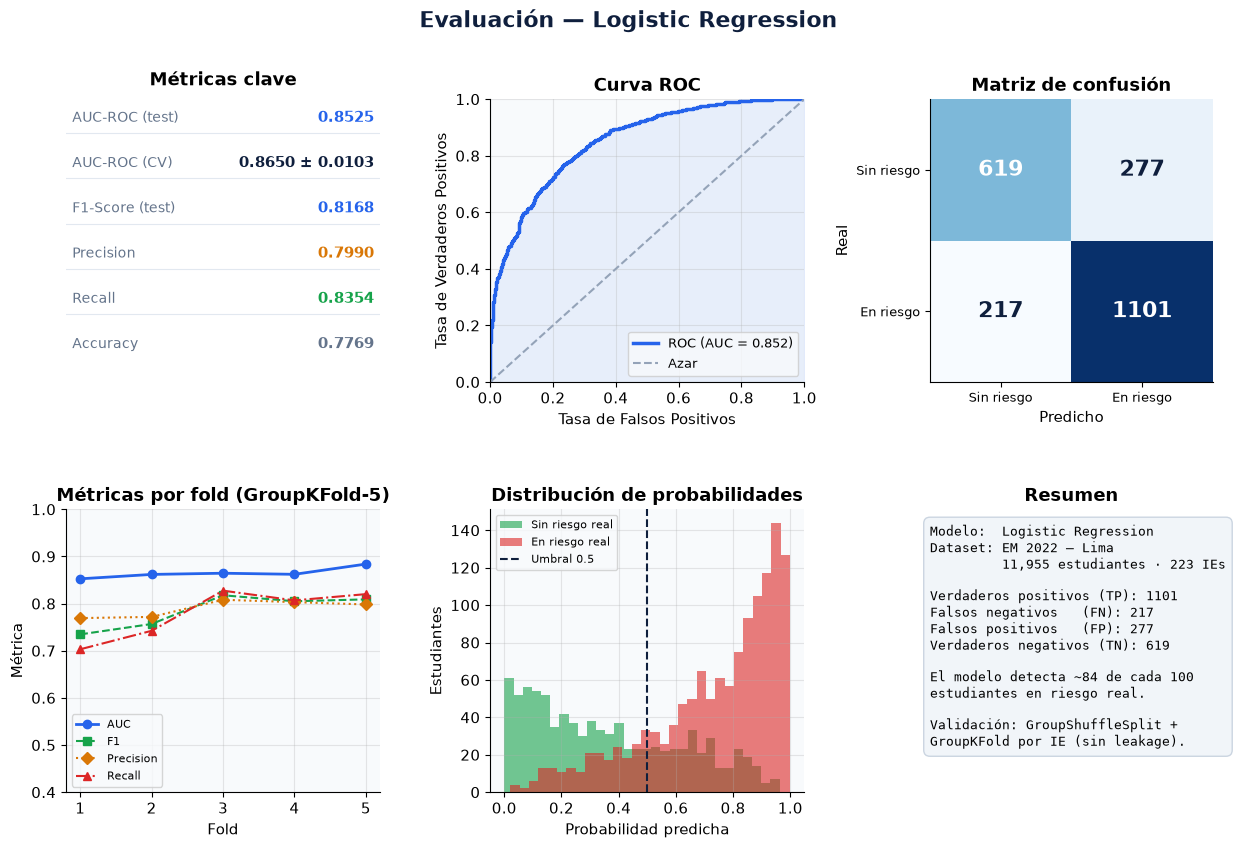

In [13]:
pipe_lr = make_pipeline(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
)
resultados_finales['Logistic Regression'] = evaluar_y_graficar(
    'Logistic Regression', pipe_lr, color='#2563eb'
)

---
## 2. Random Forest

In [ ]:
pipe_rf = make_pipeline(
    RandomForestClassifier(
        n_estimators=300, max_depth=10, class_weight='balanced',
        random_state=SEED, n_jobs=-1, monotonic_cst=MONOTONIC_CONSTRAINTS,
    )
)
resultados_finales['Random Forest'] = evaluar_y_graficar(
    'Random Forest', pipe_rf, color='#059669'
)

---
## 3. XGBoost

In [ ]:
pipe_xgb = make_pipeline(
    XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=pos_weight,
        random_state=SEED, eval_metric='logloss', verbosity=0,
        monotone_constraints=tuple(MONOTONIC_CONSTRAINTS),
    )
)
resultados_finales['XGBoost'] = evaluar_y_graficar(
    'XGBoost', pipe_xgb, color='#d97706'
)

---
## 4. LightGBM

In [ ]:
pipe_lgbm = make_pipeline(
    LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=SEED, verbosity=-1,
        monotone_constraints=MONOTONIC_CONSTRAINTS,
        monotone_constraints_method='basic',
    )
)
resultados_finales['LightGBM'] = evaluar_y_graficar(
    'LightGBM', pipe_lgbm, color='#7c3aed'
)

---
## 5. Gradient Boosting

In [ ]:
pipe_gb = make_pipeline(
    GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=SEED,
    )
)
resultados_finales['Gradient Boosting'] = evaluar_y_graficar(
    'Gradient Boosting', pipe_gb, color='#dc2626'
)

---
## 6. SVM (RBF)

In [ ]:
pipe_svm = make_pipeline(
    SVC(kernel='rbf', C=1.0, gamma='scale',
        class_weight='balanced', probability=True, random_state=SEED)
)
resultados_finales['SVM (RBF)'] = evaluar_y_graficar(
    'SVM (RBF)', pipe_svm, color='#0891b2'
)

---
## 7. Ensemble LR + RF (Soft Voting) — Modelo seleccionado

In [ ]:
pipe_lr2 = make_pipeline(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
)
pipe_rf2 = make_pipeline(
    RandomForestClassifier(
        n_estimators=300, max_depth=10, class_weight='balanced',
        random_state=SEED, n_jobs=-1, monotonic_cst=MONOTONIC_CONSTRAINTS,
    )
)
pipe_ensemble = VotingClassifier(
    estimators=[('lr', pipe_lr2), ('rf', pipe_rf2)],
    voting='soft',
)
resultados_finales['Ensemble LR+RF'] = evaluar_y_graficar(
    'Ensemble LR+RF (Modelo Final)', pipe_ensemble, color='#0f1f3d'
)

---
## Tabla comparativa

In [ ]:
df_comp = pd.DataFrame(resultados_finales).T.sort_values('AUC-ROC Test', ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')
tabla = ax.table(
    cellText=df_comp.round(4).values,
    rowLabels=df_comp.index,
    colLabels=df_comp.columns,
    cellLoc='center', loc='center',
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.2, 2.0)

for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor(COLOR_NAVY)
        cell.set_text_props(color='white', fontweight='bold')
    elif df_comp.index[row-1] == 'Ensemble LR+RF':
        cell.set_facecolor('#dbeafe')
        cell.set_text_props(fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f8fafc')

plt.title('Comparativa completa — 7 algoritmos evaluados\n'
          '(Azul = modelo seleccionado para producción)',
          fontsize=13, fontweight='bold', color=COLOR_NAVY, pad=20)
plt.tight_layout()
plt.show()
print(df_comp.to_string())